# 8: Correlation & Covariance (08_Correlation.ipynb)

**Sprint:** Sprint 2 – Statistics & Mathematics for AI/ML Engineers

## 1. Correlation and Covariance

### Definition
Covariance measures how two variables change TOGETHER - whether 
they increase/decrease at the same time. Correlation is a 
STANDARDIZED version of covariance, scaled to always fall between 
-1 and +1, making it much easier to interpret and compare across 
different variables.

### Formula
Covariance: Cov(X,Y) = Σ[(x-mean_x)(y-mean_y)] / n
Correlation: r = Cov(X,Y) / (σ_x × σ_y)

### Numerical Example
Study hours vs exam scores for 5 students tend to move together - 
more study hours, higher scores. Covariance gives a raw number 
that's hard to interpret alone; correlation converts it to a clean 
value like 0.85, immediately understandable as "strong positive relationship."

### Business Example
A retailer checks correlation between advertising spend and sales 
revenue - a strong positive correlation suggests ads are working, 
guiding future marketing budget decisions.

### AI/ML Example
Correlation is used in Feature Selection - highly correlated 
features often carry redundant information, so one might be 
dropped to reduce multicollinearity before training a model.

### Interpretation
Covariance's raw number depends on the UNITS of the variables 
(hard to compare across different datasets). Correlation removes 
that unit-dependence, always giving a value between -1 and +1, 
making it the preferred measure for interpretation.

In [1]:
import numpy as np

study_hours = [2, 4, 6, 8, 10]
exam_scores = [50, 60, 70, 85, 95]

covariance = np.cov(study_hours, exam_scores)[0][1]
correlation = np.corrcoef(study_hours, exam_scores)[0][1]

print("Covariance:", covariance)
print("Correlation:", correlation)

# Where it's used: np.cov(...)[0][1] extracts the covariance value
# between the two variables. np.corrcoef(...)[0][1] gives the
# standardized correlation - notice how much easier the correlation
# (between -1 and 1) is to interpret compared to the raw covariance number.

Covariance: 57.5
Correlation: 0.9971764649527378


## 2. Positive, Negative, and No Correlation

### Definition
Positive Correlation: as one variable increases, the other tends 
to increase too. Negative Correlation: as one increases, the other 
tends to DECREASE. No Correlation: no consistent relationship 
between the two variables at all.

### Numerical Example
Positive: Study hours & exam scores (both go up together)
Negative: Hours of TV watched & exam scores (more TV, lower scores)
No Correlation: Shoe size & exam scores (unrelated)

### Business Example
Positive: Ad spend & sales revenue. Negative: Product price & 
quantity sold (as price increases, demand often drops). No 
Correlation: Employee's favorite color & their sales performance.

### AI/ML Example
Understanding correlation direction helps interpret which features 
push a model's prediction UP vs DOWN - critical for model 
interpretability and building trust in predictions.

In [2]:
import numpy as np

hours_study = [2, 4, 6, 8, 10]
scores_positive = [50, 60, 70, 85, 95]        # positive correlation
hours_tv = [8, 6, 4, 2, 1]
scores_negative = [50, 60, 70, 85, 95]        # negative correlation (inverse of TV hours)
random_values = [23, 87, 12, 56, 4]           # unrelated to scores

print("Positive correlation (study hrs vs scores):", np.corrcoef(hours_study, scores_positive)[0][1])
print("Negative correlation (TV hrs vs scores):", np.corrcoef(hours_tv, scores_negative)[0][1])
print("No/weak correlation (random vs scores):", np.corrcoef(random_values, scores_positive)[0][1])

# Where it's used: the first correlation is strongly POSITIVE
# (close to +1), the second is strongly NEGATIVE (close to -1), and
# the third is close to 0, showing little to no real relationship -
# directly demonstrating all three correlation types numerically.

Positive correlation (study hrs vs scores): 0.9971764649527378
Negative correlation (TV hrs vs scores): -0.991077469115864
No/weak correlation (random vs scores): -0.29937998186628906


## 3. Pearson Correlation

### Definition
Pearson Correlation measures the STRENGTH and DIRECTION of a 
LINEAR relationship between two continuous variables. It's the 
most common correlation coefficient, assuming both variables are 
roughly normally distributed.

### Formula
r = Σ[(x-mean_x)(y-mean_y)] / √[Σ(x-mean_x)² × Σ(y-mean_y)²]

### Where it is used
Used when checking for LINEAR relationships between two numeric 
variables - the default correlation method in most statistical software.

### Real-world Example
Checking correlation between a person's height and weight - 
generally a linear, positive relationship well-suited to Pearson correlation.

### AI/ML Example
Used extensively in Feature Selection to identify which numeric 
features have a strong linear relationship with the target 
variable, or with each other (for detecting multicollinearity).

In [3]:
from scipy.stats import pearsonr

height = [160, 165, 170, 175, 180]
weight = [55, 60, 68, 72, 80]

corr, p_value = pearsonr(height, weight)
print("Pearson Correlation:", corr)
print("P-value:", p_value)

# Where it's used: pearsonr() returns both the correlation
# coefficient AND a p-value (indicating statistical significance).
# A correlation close to +1 here confirms a strong, linear positive
# relationship between height and weight in this sample.

Pearson Correlation: 0.9953500135552997
P-value: 0.000380371734133282


## 4. Spearman Correlation

### Definition
Spearman Correlation measures the strength of a MONOTONIC 
relationship (consistently increasing or decreasing, but not 
necessarily in a straight line) between two variables, based on 
the RANKS of the values rather than their raw values. Useful when 
data isn't linear or isn't normally distributed.

### Formula
Based on ranking both variables, then calculating Pearson 
correlation on those RANKS instead of raw values.

### Where it is used
Used for non-linear but monotonic relationships, ordinal data 
(like rankings/ratings), or when data has outliers that would 
distort Pearson correlation.

### Real-world Example
Correlation between customer satisfaction RATING (1-5 stars) and 
likelihood to recommend a product - both are ordinal/ranked data, 
better suited to Spearman than Pearson.

### AI/ML Example
Used when features have a non-linear but consistent relationship - 
Spearman can detect a relationship that Pearson might miss or 
underestimate, since Pearson only captures LINEAR patterns.

In [4]:
from scipy.stats import spearmanr

satisfaction_rating = [1, 2, 3, 4, 5]
recommend_likelihood = [10, 25, 45, 80, 95]   # non-linear but monotonic increase

corr, p_value = spearmanr(satisfaction_rating, recommend_likelihood)
print("Spearman Correlation:", corr)

# Where it's used: spearmanr() ranks both variables first, then
# correlates the ranks. Even though recommend_likelihood doesn't
# increase in perfectly equal linear steps, Spearman still detects
# the strong MONOTONIC relationship (both consistently increase together).

Spearman Correlation: 0.9999999999999999


## 5. Correlation Matrix and Heatmap

### Definition
A Correlation Matrix shows the correlation coefficient between 
EVERY PAIR of variables in a dataset, arranged in a grid/table. A 
Heatmap is a color-coded VISUALIZATION of that matrix, making 
patterns instantly visible without reading raw numbers.

### Where it is used
Used to quickly scan for relationships across MANY variables at 
once, especially useful before feature selection in ML, when 
checking dozens of features individually would be impractical.

### Real-world Example
A hospital analyzing patient data (age, blood pressure, cholesterol, 
weight) uses a correlation matrix/heatmap to instantly spot which 
health metrics move together.

### AI/ML Example
Correlation Heatmaps are a standard first step in Exploratory Data 
Analysis (EDA) - engineers scan for highly correlated feature 
pairs (multicollinearity) that might need to be addressed before 
model training.

Correlation Matrix:
                     age  blood_pressure  cholesterol  exercise_hours
age             1.000000        0.995603     0.992061       -0.994432
blood_pressure  0.995603        1.000000     0.992375       -0.996758
cholesterol     0.992061        0.992375     1.000000       -0.997745
exercise_hours -0.994432       -0.996758    -0.997745        1.000000


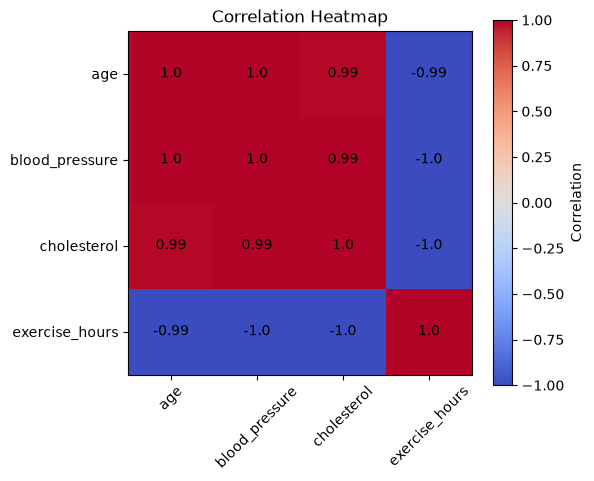

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.DataFrame({
    "age": [25, 32, 47, 51, 62],
    "blood_pressure": [110, 118, 135, 142, 150],
    "cholesterol": [180, 190, 210, 225, 240],
    "exercise_hours": [10, 8, 5, 3, 1]
})

corr_matrix = data.corr()
print("Correlation Matrix:")
print(corr_matrix)

plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap")
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, round(corr_matrix.iloc[i,j], 2), ha="center", va="center")
plt.tight_layout()
plt.show()

# Where it's used: data.corr() computes the FULL correlation matrix
# across all 4 columns at once - every variable pair's correlation
# in one table. The heatmap colors each cell by correlation
# strength (red=positive, blue=negative), making it instantly clear
# that age/blood_pressure/cholesterol move together, while
# exercise_hours moves OPPOSITE to them.